# Exercise 6.1 — Converting a Second-Order ODE to First-Order Form

**Textbook:** Sayama, *Introduction to the Modeling and Analysis of Complex Systems*

---

## Problem Statement

Convert the following second-order ODE into a system of first-order differential equations:

$$\frac{d^2x}{dt^2} - x\frac{dx}{dt} + x^2 = 0$$

---

## Step 1 — Introduce an Auxiliary Variable

Any second-order ODE can be rewritten as a two-equation first-order system by treating the first derivative as a new variable. Define:

$$v = \frac{dx}{dt}$$

Then the second derivative is just the time-derivative of $v$:

$$\frac{d^2x}{dt^2} = \frac{dv}{dt}$$

Substitute into the original equation:

$$\frac{dv}{dt} - xv + x^2 = 0$$

Solve for $\frac{dv}{dt}$:

$$\frac{dv}{dt} = xv - x^2 = x(v - x)$$

---

## First-Order System

$$\boxed{\frac{dx}{dt} = v}$$

$$\boxed{\frac{dv}{dt} = x(v - x)}$$

This is a **nonlinear** autonomous system in the state variables $(x, v)$. The nonlinearity comes from the $xv$ and $x^2$ terms in the second equation.

---

## Step 2 — Find the Equilibria

Set both derivatives to zero:

$$\frac{dx}{dt} = v = 0$$

$$\frac{dv}{dt} = x(v - x) = 0 \quad \Rightarrow \quad x(0 - x) = -x^2 = 0 \quad \Rightarrow \quad x = 0$$

There is exactly one equilibrium: $(x^*, v^*) = (0, 0)$.

---

## Step 3 — Linearize at the Equilibrium

The Jacobian of the right-hand side $\mathbf{F}(x, v) = [v,\; x(v-x)]^\top$ is:

$$J(x,v) = \begin{bmatrix} \partial(v)/\partial x & \partial(v)/\partial v \\ \partial[x(v-x)]/\partial x & \partial[x(v-x)]/\partial v \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ v - 2x & x \end{bmatrix}$$

At $(0, 0)$:

$$J(0,0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$$

The characteristic polynomial is $\lambda^2 = 0$, giving a **repeated zero eigenvalue** ($\lambda = 0$). This is a **nilpotent Jacobian** — the origin is a non-hyperbolic equilibrium, so the standard linearization theorem doesn't tell us the stability directly. We need the phase portrait to see what the nonlinear system actually does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def system(t, state):
    """Right-hand side of the first-order system."""
    x, v = state
    dxdt = v
    dvdt = x * (v - x)
    return [dxdt, dvdt]

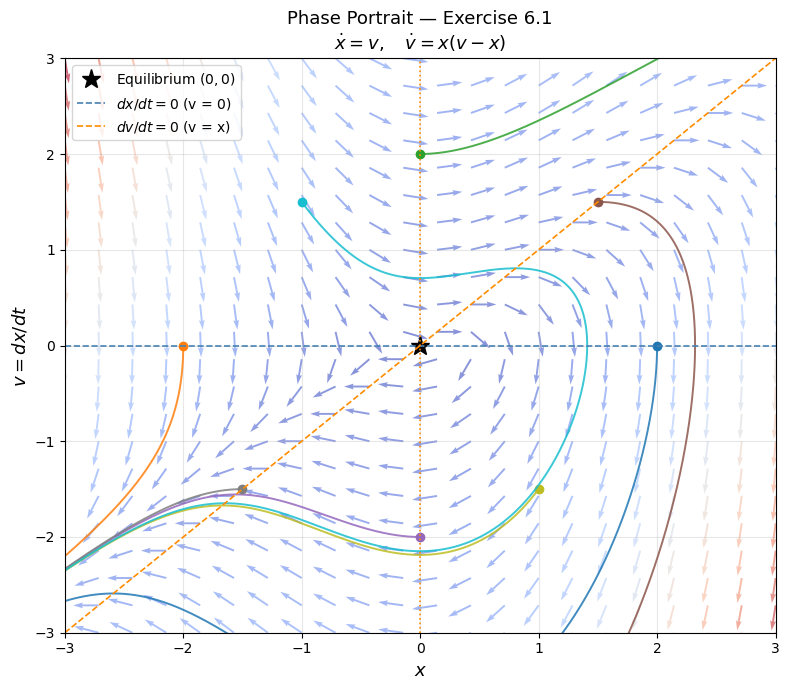

In [3]:
# --- Phase portrait: vector field + selected trajectories ---

fig, ax = plt.subplots(figsize=(8, 7))

# Vector field
grid = np.linspace(-3, 3, 22)
X, V = np.meshgrid(grid, grid)
dX = V
dV = X * (V - X)
norm = np.sqrt(dX**2 + dV**2)
norm[norm == 0] = 1
ax.quiver(X, V, dX / norm, dV / norm, norm, cmap='coolwarm', alpha=0.6, scale=28)

# Trajectory integration
t_span = (0, 6)
t_eval = np.linspace(*t_span, 2000)

initial_conditions = [
    [2.0,  0.0],
    [-2.0, 0.0],
    [0.0,  2.0],
    [0.0, -2.0],
    [1.5,  1.5],
    [-1.5, -1.5],
    [1.0, -1.5],
    [-1.0,  1.5],
]

colors = plt.cm.tab10(np.linspace(0, 1, len(initial_conditions)))

for ic, color in zip(initial_conditions, colors):
    sol = solve_ivp(system, t_span, ic, t_eval=t_eval, rtol=1e-8, atol=1e-10)
    # Clip to plot range to handle blow-up
    x_clip = np.clip(sol.y[0], -4, 4)
    v_clip = np.clip(sol.y[1], -4, 4)
    ax.plot(x_clip, v_clip, color=color, linewidth=1.4, alpha=0.85)
    ax.plot(ic[0], ic[1], 'o', color=color, markersize=6)

# Equilibrium
ax.plot(0, 0, 'k*', markersize=14, label='Equilibrium $(0,0)$')

# Nullclines
xx = np.linspace(-3, 3, 300)
ax.axhline(0, color='steelblue', linewidth=1.2, linestyle='--', label=r'$dx/dt=0$ (v = 0)')
ax.plot(xx, xx, color='darkorange', linewidth=1.2, linestyle='--', label=r'$dv/dt=0$ (v = x)')
ax.axvline(0, color='darkorange', linewidth=1.2, linestyle=':')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$v = dx/dt$', fontsize=13)
ax.set_title('Phase Portrait — Exercise 6.1\n'
             r'$\dot{x}=v,\quad \dot{v}=x(v-x)$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

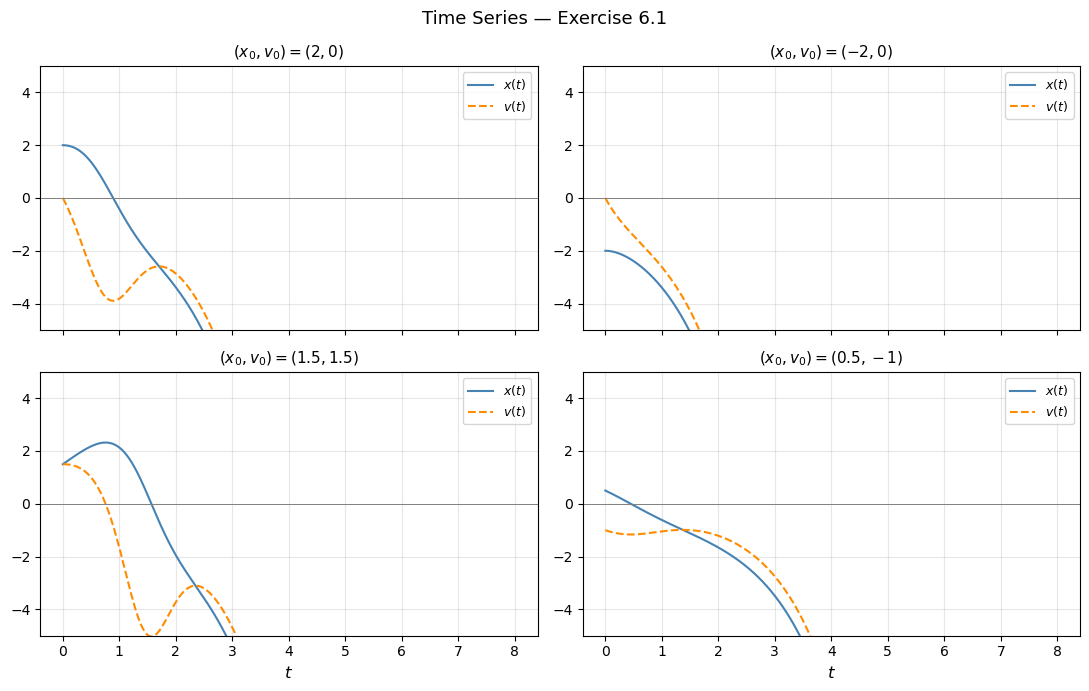

: 

In [ ]:
# --- Time series for a few trajectories ---

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
sample_ics = [[2.0, 0.0], [-2.0, 0.0], [1.5, 1.5], [0.5, -1.0]]
titles = ['$(x_0, v_0) = (2, 0)$', '$(x_0, v_0) = (-2, 0)$',
          '$(x_0, v_0) = (1.5, 1.5)$', '$(x_0, v_0) = (0.5, -1)$']

t_long = np.linspace(0, 8, 3000)

for ax, ic, title in zip(axes.flat, sample_ics, titles):
    sol = solve_ivp(system, (0, 8), ic, t_eval=t_long, rtol=1e-8, atol=1e-10)
    ax.plot(sol.t, sol.y[0], label='$x(t)$', color='steelblue')
    ax.plot(sol.t, sol.y[1], label='$v(t)$', color='darkorange', linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-5, 5)
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('$t$', fontsize=12)

fig.suptitle('Time Series — Exercise 6.1', fontsize=13)
plt.tight_layout()
plt.show()

---

## Summary

| Step | Result |
|------|--------|
| Substitution | $v = dx/dt$ reduces order by 1 |
| First-order system | $\dot{x} = v$, $\dot{v} = x(v - x)$ |
| Only equilibrium | $(x^*, v^*) = (0, 0)$ |
| Jacobian at origin | $\begin{bmatrix}0&1\\0&0\end{bmatrix}$ — nilpotent, eigenvalue $\lambda = 0$ (repeated) |
| Stability verdict | **Non-hyperbolic** — linearization is inconclusive; phase portrait shows origin is a saddle-like point for the nonlinear flow |

The key takeaway from the phase portrait: trajectories that start near the diagonal $v = x$ follow it closely (the $dv/dt = 0$ nullcline runs along $v = x$), while those that start above or below diverge. The origin sits at the intersection of both nullclines and acts as a weak, non-hyperbolic fixed point.